Intercept: 23.991585693073176
Coefficients: [-1.53841144 -0.07583296]


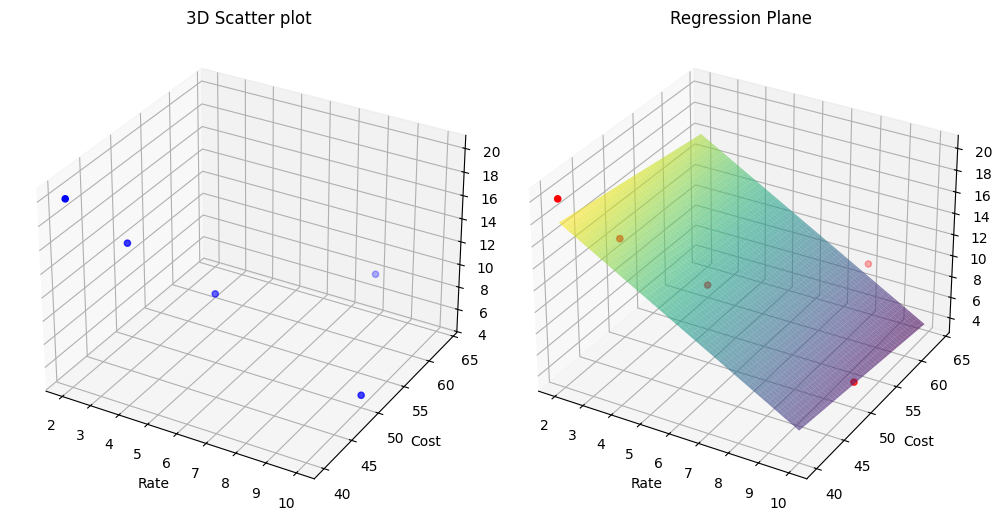

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

# Data for Quality, Rate, and Cost
quality = np.array([10, 15, 20, 5, 8])
rate = np.array([5, 3, 2, 10, 8])
cost = np.array([50, 45, 40, 50, 64])

# Reshape data for linear regression
X = np.column_stack((rate, cost))  # Independent variables (Rate, Cost)
y = quality  # Dependent variable (Quality)

# Initialize and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Get the coefficients and intercept
intercept = model.intercept_
coefficients = model.coef_

# Display results
print(f"Intercept: {intercept}")
print(f"Coefficients: {coefficients}")

# Create a grid for plotting the regression surface
rate_range = np.linspace(min(rate), max(rate), 100)
cost_range = np.linspace(min(cost), max(cost), 100)
rate_grid, cost_grid = np.meshgrid(rate_range, cost_range)
predicted_quality = model.predict(np.column_stack((rate_grid.ravel(), cost_grid.ravel()))).reshape(rate_grid.shape)

# Plotting 3D scatter plot and regression plane
fig = plt.figure(figsize=(10, 6))

# 3D scatter plot
ax = fig.add_subplot(121, projection='3d')
ax.scatter(rate, cost, quality, color='blue', label='Data points')
ax.set_xlabel('Rate')
ax.set_ylabel('Cost')
ax.set_zlabel('Quality')
ax.set_title('3D Scatter plot')

# 3D surface plot (regression plane)
ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(rate_grid, cost_grid, predicted_quality, cmap='viridis', alpha=0.6)
ax.scatter(rate, cost, quality, color='red', label='Data points')
ax.set_xlabel('Rate')
ax.set_ylabel('Cost')
ax.set_zlabel('Quality')
ax.set_title('Regression Plane')

plt.tight_layout()
plt.show()


Intercept: 50.000000000000014
Coefficients: [-1.  -0.7]
Training R²: 1.0
Test R²: -3.7710204081632686

=== TRAIN SET: Actual vs Predicted ===
   Rate  Cost  Actual_Quality  Predicted_Quality
2     2    40              20               20.0
0     5    50              10               10.0
3    10    50               5                5.0

=== TEST SET: Actual vs Predicted ===
   Rate  Cost  Actual_Quality  Predicted_Quality
1     3    45              15               15.5
4     8    64               8               -2.8


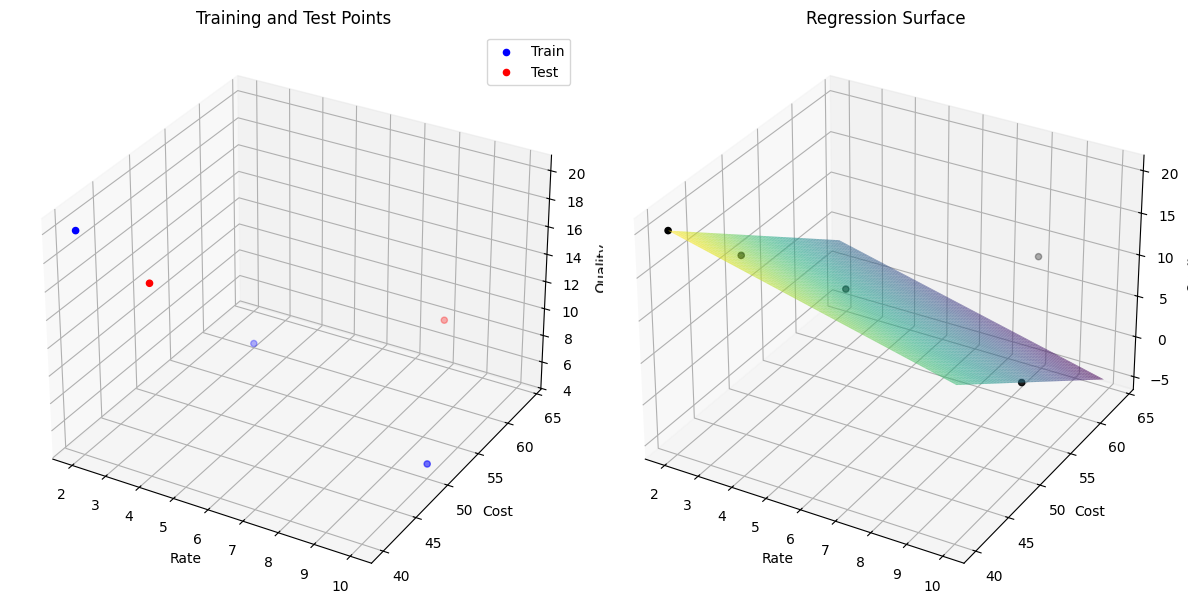

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------
# 1. Create DataFrame
# ---------------------------------------------------------
df = pd.DataFrame({
    'Quality': [10, 15, 20, 5, 8],
    'Rate': [5, 3, 2, 10, 8],
    'Cost': [50, 45, 40, 50, 64]
})

# Inputs and output
X = df[['Rate', 'Cost']]
y = df['Quality']

# ---------------------------------------------------------
# 2. Train/Test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ---------------------------------------------------------
# 3. Train the Linear Regression model
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Display model details
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Training R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

# ---------------------------------------------------------
# 4. Actual vs Predicted Table
# ---------------------------------------------------------
train_results = pd.DataFrame({
    'Rate': X_train['Rate'],
    'Cost': X_train['Cost'],
    'Actual_Quality': y_train,
    'Predicted_Quality': y_train_pred
})

test_results = pd.DataFrame({
    'Rate': X_test['Rate'],
    'Cost': X_test['Cost'],
    'Actual_Quality': y_test,
    'Predicted_Quality': y_test_pred
})

print("\n=== TRAIN SET: Actual vs Predicted ===")
print(train_results)

print("\n=== TEST SET: Actual vs Predicted ===")
print(test_results

# ---------------------------------------------------------
# 5. Create grid for regression surface
# ---------------------------------------------------------
rate_range = np.linspace(df['Rate'].min(), df['Rate'].max(), 100)
cost_range = np.linspace(df['Cost'].min(), df['Cost'].max(), 100)
rate_grid, cost_grid = np.meshgrid(rate_range, cost_range)

grid_df = pd.DataFrame({
    'Rate': rate_grid.ravel(),
    'Cost': cost_grid.ravel()
})

predicted_surface = model.predict(grid_df).reshape(rate_grid.shape)

# ---------------------------------------------------------
# 6. Plotting
# ---------------------------------------------------------
fig = plt.figure(figsize=(12, 6))

# 3D scatter: Train vs Test
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X_train['Rate'], X_train['Cost'], y_train, color='blue', label="Train")
ax.scatter(X_test['Rate'], X_test['Cost'], y_test, color='red', label="Test")
ax.set_xlabel('Rate')
ax.set_ylabel('Cost')
ax.set_zlabel('Quality')
ax.set_title('Training and Test Points')
ax.legend()

# Regression Surface
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(rate_grid, cost_grid, predicted_surface, cmap='viridis', alpha=0.6)
ax2.scatter(df['Rate'], df['Cost'], df['Quality'], color='black')
ax2.set_xlabel('Rate')
ax2.set_ylabel('Cost')
ax2.set_zlabel('Quality')
ax2.set_title('Regression Surface')

plt.tight_layout()
plt.show()
